# Laboratorium 2 - sprawozdanie
Autor: Szymon Januszek

## Zadanie 1 Metoda Gaussa-Jordana
Napisz i sprawdź funkcję rozwiązującą układ równań liniowych n × n metodą Gaussa-Jordana z częściowym poszukiwaniem elementu wiodącego. Dla dziesięciu różnych rozmiarów macierzy współczynników większych niż 500 × 500 porównaj czasy działania zaimplementowanej funkcji z czasami uzyskanymi dla wybranych funkcji bibliotecznych.

### Import wymaganych bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

## Implementacja metody Gaussa-Jordana z częściowym poszukiwaniem elementu wiodącego

In [2]:
def gauss_jordan(A,B):
    n = len(A)
    A_ext = np.concatenate((A,np.resize(B,(n,1))),axis=1)
    for i in range(n):
        max_factor_id = np.argmax(A_ext[i:, i]) + i
        A_ext[[i,max_factor_id]] = A_ext[[max_factor_id,i]]

        A_ext[i] /= A_ext[i][i]

        for j in range(i+1,n):
            mult_fact = -A_ext[j][i] / A_ext[i][i]
            A_ext[j] += A_ext[i] * mult_fact 

    return A_ext[:, :-1], A_ext[:, -1]

## Funkcje pomocnicze:

### Podstawienie wsteczne

In [3]:
def back_sub(A,B):
    n = len(A)
    res = np.zeros(n)

    for i in range(n-1,-1,-1):
        res[i] = (B[i] - np.dot(A[i,i+1:],res[i+1:])) / A[i][i]

    return res

### Rozwiązywanie układu

In [4]:
def solve(A,B):
    upper, new = gauss_jordan(A,B)
    return back_sub(upper,new)

## Testy wydajnościowe i poprawnościowe

In [5]:
N = [500,600,700,800,900,1000,1400,1800,2200,2500]
x_axis = N
time_gj = []
time_np = []

for n in N:
    A = np.random.rand(n,n)
    B = np.random.rand(n)

    gj_time1 = time()
    res1 = solve(A,B)
    gj_time2 = time()
    time_gj.append(gj_time2-gj_time1)

    np_time1 = time()
    res2 = np.linalg.solve(A,B)
    np_time2 = time()
    time_np.append(np_time2-np_time1)

    is_correct = np.allclose(res1,res2)

    print(f"For random matrix {n}x{n}\nGauss Jordan time: {gj_time2 - gj_time1}\nNumPy time: {np_time2 - np_time1}\nCorrect: {is_correct}\n")

For random matrix 500x500
Gauss Jordan time: 0.3807802200317383
NumPy time: 0.03220486640930176
Correct: True

For random matrix 600x600
Gauss Jordan time: 0.5923135280609131
NumPy time: 0.05254387855529785
Correct: True

For random matrix 700x700
Gauss Jordan time: 0.7096884250640869
NumPy time: 0.06865668296813965
Correct: True

For random matrix 800x800
Gauss Jordan time: 0.932276725769043
NumPy time: 0.1006312370300293
Correct: True

For random matrix 900x900
Gauss Jordan time: 1.219709873199463
NumPy time: 0.16918301582336426
Correct: True

For random matrix 1000x1000
Gauss Jordan time: 1.6852352619171143
NumPy time: 0.20433712005615234
Correct: True

For random matrix 1400x1400
Gauss Jordan time: 3.860854387283325
NumPy time: 0.5604252815246582
Correct: True

For random matrix 1800x1800
Gauss Jordan time: 6.695682048797607
NumPy time: 1.1867711544036865
Correct: True

For random matrix 2200x2200
Gauss Jordan time: 10.897706508636475
NumPy time: 2.083916425704956
Correct: True

Fo

Text(0, 0.5, 'Time [s]')

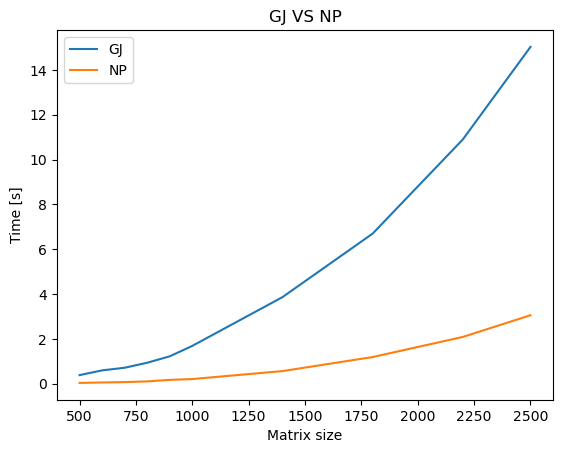

In [6]:
fig, axs = plt.subplots()
axs.plot(x_axis, time_gj, label = "GJ")
axs.plot(x_axis, time_np, label = "NP")
axs.legend()
axs.set_title("GJ VS NP")
axs.set_xlabel("Matrix size")
axs.set_ylabel("Time [s]")

## Zadanie 2 Faktoryzacja LU
Napisz i przetestuj funkcję dokonującą faktoryzacji **A** = **LU** macierzy **A** (bez poszukiwania elementu wiodącego). Sprawdź poprawność wyniku obliczając ∥**A** − **LU**∥. Zadbaj o to żeby implementacja była in-situ. Elementy macierzy **L** to współczynniki mnożenia umożliwiające wyzerowanie odpowiedniego współczynnika macierzy **A** w trakcie procesu eliminacji.

### Import wymaganych bibliotek

In [7]:
import numpy as np
from time import time

## Implementacja faktoryzacji LU

In [8]:
def factorize_LU(A):
    n = len(A)
    U = A.copy()
    L = np.eye(n)

    for i in range(n):
        for j in range(i+1,n):
            L[j][i] = U[j][i] / U[i][i]
            U[j] -= U[i] * L[j][i]

    return L, U

## Testy wydajnościowe i poprawnościowe

In [9]:
N = [500,600,700,800,900,1000,1400,1800,2200,2500]

for n in N:
    A = np.random.rand(n,n)
    A_org = A.copy()

    lu_time1 = time()
    L,U = factorize_LU(A)
    lu_time2 = time()

    err = np.linalg.norm(A_org - L @ U)
    print(f"For random matrix {n}x{n}\nTime: {lu_time2-lu_time1}\nAboulute erorr: {err}\n")

For random matrix 500x500
Time: 0.4039623737335205
Aboulute erorr: 3.148458338410079e-11

For random matrix 600x600
Time: 0.5685627460479736
Aboulute erorr: 1.9591688615372434e-10

For random matrix 700x700
Time: 0.8543679714202881
Aboulute erorr: 2.7394481485878722e-11

For random matrix 800x800
Time: 1.028886079788208
Aboulute erorr: 4.397379327174218e-11

For random matrix 900x900
Time: 1.467998743057251
Aboulute erorr: 1.4005868826452806e-09

For random matrix 1000x1000
Time: 1.8716957569122314
Aboulute erorr: 8.577785023847265e-11

For random matrix 1400x1400
Time: 4.152317523956299
Aboulute erorr: 3.4647430852670145e-09

For random matrix 1800x1800
Time: 7.196164846420288
Aboulute erorr: 5.565518732860736e-10

For random matrix 2200x2200
Time: 11.714145183563232
Aboulute erorr: 1.4285819349695792e-07

For random matrix 2500x2500
Time: 15.957504510879517
Aboulute erorr: 2.8370643352152226e-09



# Zadanie 3 Analiza obwodu elektrycznego - nadokreślony układ równań
Napisz program, który:

a) Wczytuje z pliku listę krawędzi grafu nieskierowanego ważonego opisującego obwód elektryczny. Wagi krawędzi określają opór fragmentu obwodu między dwoma węzłami. Wierzchołki grafu identyfikowane są przez liczby naturalne.

b) Wczytuje dodatkowo trójkę liczb (s, t, E), przy czym para (s, t) wskazuje między którymi węzłami sieci przyłożono siłę elektromotoryczną E. Opór wewnętrzny SEM można zaniedbać.

c) Wykorzystując prawa Kirchhoffa (albo metodę potencjałów węzłowych) znajduje natężenia prądu w każdej części obwodu i przedstawia je na rysunku w postaci grafu ważonego z etykietami (wizualizacja grafu wraz z kolorowymi krawędziami pokazującymi wartość natężenia prądu oraz jego kierunek)

d) Przedstaw (wizualizacja + automatyczne sprawdzenie poprawności wyników) dzia łanie programu dla grafów spójnych mających od 15 do 200 wierzchołków. Rozważ następujące typy grafów:
- Spójny graf losowy (Erdős-Rényi)
- Graf 3-regularny (kubiczny)
- Graf złożony z dwóch grafów losowych połaczonych mostkiem
- Graf siatka 2D
- Graf typu small-world

e) Skomentuj wybrane rozwiązanie - prawa Kirchoffa I, II vs. metoda potencjałów węzłowych. W przypadku korzystania z praw Kirchoffa - w jaki sposób możemy rozwiązać nadokreślony układ równań. Opisz najważniejsze aspekty swojego rozwiązania (kierunek prądu, weryfikacja poprawności rozwiązania, sposób wyznaczania cykli prostych).

### Import wymaganych bibliotek

In [10]:
import networkx as nx
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from time import time

## Wyznaczanie natężeń przy użyciu praw Kirchoffa
Funkcja tworzy macierz równań o rozmiarach (m - 1 + g)x(n) gdzie:
 - n - liczba krawędzi
 - m - liczba wierzchołków
 - g - liczba cykli
   
(potrzebujemy tylko m - 1 równań dla wierzchołków ponieważ, jeśli m - 1 równań jest spełnione to ostatnie też jest spełnione)

Następnie przechodzi po kolejnych węzłach wpisując do macierzy równania dla prądów wpływających i wypływających zgodnie z pierwszym prawem Kirchoffa, oraz po wszystkich cyklach wpisując do macierzy równania dla sum spadków napięć w oczkach zgodnie z drugim prawem Kirchoffa. W ten sposób utworzony układ nadokreślony jest rozwiązywany za pomocą `np.linalg.solve` i zwracana jest tablica natężeń dla krawędzi.

In [11]:
def solve_kirhoff(G, s, t, E):
    # added edge represents the power source
    G.add_edge(s,t, resistance = 0)

    # we can find the needed cycles using the cycle_basis function from networkx
    cycles = nx.cycle_basis(G)
    edges = list(G.edges)
    
    # map for later quick lookups
    edges_map = {tuple(edge): i for i, edge in enumerate(edges)}
    nodes = list(G.nodes)

    n = len(edges)
    m = len(nodes)
    g = len(cycles)

    matrix = np.zeros((m - 1 + g,n))
    res = np.zeros(m - 1 + g)

    # KCL for m - 1 nodes (1 and -1 assigned arbitrarily)
    for i in range(m - 1):
        for j in range(n):
            if edges[j][0] == i:
                matrix[i,j] = -1
            elif edges[j][1] == i:
                matrix[i,j] = 1

    # KVL
    for i, cycle in enumerate(cycles):
        row_id = i + m - 1
        for j, node in enumerate(cycle):
            next_node = cycle[(j + 1) % len(cycle)]
            if (node, next_node) == (s, t):
                res[row_id] += E
            elif (node, next_node) == (t, s):
                res[row_id] -= E

            if (node, next_node) in edges_map:
                matrix[row_id, edges_map.get((node,next_node))] = G.edges[node, next_node]['resistance']
            else:
                matrix[row_id, edges_map.get((next_node,node))] = -G.edges[next_node, node]['resistance']
                
    # we solve the overdetermined matrix using the solve function from numpy because of it's performance and return the currents
    return np.linalg.solve(matrix,res)### Poprawność i wizualizacje Kirchoff

## Wyznaczanie potencjałów przy użyciu metody potencjałów wezłowych
Funkcja tworzy macierz równań o rozmiarach (m)x(m) gdzie:

- m - liczba wierzchołków

Następnie przechodzi po kolejnych węzłach i korzystając z pierwszego prawa Kirchoffa wyznacza równania dla prądów wpływających i wypływających oraz konduktancje gałęzi. Dla wierzchołków _s_ i _t_ narzucamy odpowiednio potencjał _E_ or 0V.  W ten sposób utworzony układ nadokreślony jest rozwiązywany za pomocą `np.linalg.solve` i zwracana jest tablice potencjałów.

In [12]:
def solve_nodal(G, s, t, E): 
    nodes = list(G.nodes)
    m = len(nodes)
    
    # map for later quick lookups
    nodes_map = {node: i for i, node in enumerate(nodes)}

    matrix = np.zeros((m, m))
    res = np.zeros(m)

    for i, node in enumerate(nodes):
        if node == t:
            # ground node
            matrix[i, i] = 1
            res[i] = 0
        elif node == s:
            # source node
            matrix[i, i] = 1
            res[i] = E
        else:
            # KCL 
            for neighbor in G.neighbors(node):
                R = G.edges[node, neighbor]['resistance']
                
                g = 1 / R  
                
                matrix[i, i] += g
                matrix[i, nodes_map[neighbor]] -= g

    return np.linalg.solve(matrix, res)

## Weryfikacja otrzymanych natężeń

### Weryfikacja zgodności z pierwszym prawem Kirchoffa

In [13]:
def verify_KCL(solG, s, t, eps=1e-6) -> bool:
    nodes = solG.nodes

    for node in nodes:
        if node == s or node == t:
            continue

        out_edge_sum = sum([data['current'] for _,_,data in solG.out_edges(node,data=True)])
        in_edge_sum = sum([data['current'] for _,_,data in solG.in_edges(node,data=True)])
        
        if abs(out_edge_sum - in_edge_sum) > eps:
            return False

    return True

### Weryfikacja zgodności z drugim prawem Kirchoffa

In [14]:
def verify_KVL(solG, s, t, E, eps=1e-6):
    cycles = nx.cycle_basis(solG.to_undirected())

    for cycle in cycles:
        sum_edges = 0
        for j,node in enumerate(cycle):
            next_node = cycle[(j+1) % len(cycle)]
            if solG.has_edge(node,next_node):
                sum_edges += solG.edges[node,next_node]['current'] * solG.edges[node,next_node]['resistance']
            else:
                sum_edges -= solG.edges[next_node,node]['current'] * solG.edges[next_node,node]['resistance']

            if node == s and next_node == t:
                sum_edges -= E
            elif node == t and next_node == s:
                sum_edges += E

        if sum_edges > eps:
            return False

    return True

### Weryfikacja zgodności z oboma prawami

In [15]:
def verify_graph(solG, s, t, E):
    return verify_KCL(solG, s, t) and verify_KVL(solG,s,t,E)

## Generacja grafów testowych

### Zapis grafu do pliku

In [16]:
def write_to_file(G, file_name):
    directory = os.getcwd()
    os.makedirs(f"{directory}/test_graphs",exist_ok=True)

    nx.write_edgelist(G,f"{directory}/test_graphs/{file_name}")

### Dodanie losowych wartości oporu na krawędziach

In [17]:
def add_random_resistance(G):
    for (u,v) in G.edges():
        G.edges[u,v]['resistance'] = np.random.uniform(0.5,10) 
    return G

### Generacja losowych danych testowych i ich zapis
Wygenerowane grafy zostaną zapisane do folderu `test_graphs` w formacie {nazwa_grafu}_{liczność_wierzchołków}.txt

In [18]:
def generate_graphs(n):
    left = nx.erdos_renyi_graph(n//2, 0.3)
    right = nx.erdos_renyi_graph(n//2, 0.3)
    barbell = nx.disjoint_union(left,right)
    barbell.add_edge(0,n//2)

    graphs = {
            f"erdos_renyi_{n}.txt": nx.erdos_renyi_graph(n, 0.2),
            f"3_regular_{n}.txt": nx.random_regular_graph(3, n),
            f"barbell_{n}.txt": barbell,
            f"grid_2d_{n}.txt": nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(n**0.5),int(n**0.5))),
            f"watts_strogatz_{n}.txt": nx.watts_strogatz_graph(n, 4, 0.2)
            }

    for file_name, graph in graphs.items() :
        graph_weighted = add_random_resistance(graph)
        write_to_file(graph_weighted, file_name)

## Funkcje pomocnicze

### Zamiana grafu wejściowego na graf skierowany zgodnie z otrzymanymi natężeniami

In [19]:
def to_DiGraph(G, s, t, results):
    solG = nx.DiGraph()

    if len(results) == G.number_of_edges():
        for i, (u,v) in enumerate(G.edges):
            if results[i] >= 0:
                solG.add_edge(u,v)
                solG.edges[u,v]['current'] = results[i]
                solG.edges[u,v]['resistance'] = G.edges[u,v]['resistance']
            else:
                solG.add_edge(v,u)
                solG.edges[v,u]['current'] = -results[i]
                solG.edges[v,u]['resistance'] = G.edges[u,v]['resistance']
    elif len(results) == G.number_of_nodes():
        nodes = list(G.nodes)
        nodes_map = {node: i for i, node in enumerate(nodes)}

        for u,v in G.edges:
            if (u == s and v == t) or (u == t and v ==s ):
                continue
            V_u = results[nodes_map[u]]
            V_v = results[nodes_map[v]]

            I = (V_u - V_v) / G.edges[u,v]['resistance']

            if I >= 0:
                solG.add_edge(v,u)
                solG.edges[v,u]['current'] = I
                solG.edges[v,u]['resistance'] = G.edges[u,v]['resistance']
            else:
                solG.add_edge(u,v)
                solG.edges[u,v]['current'] = -I
                solG.edges[u,v]['resistance'] = G.edges[u,v]['resistance']

        # edge between power source and ground target with correct current
        I_virtual = sum(data['current'] for _,_,data in solG.out_edges(s,data=True)) - sum(data['current'] for _,_,data in solG.in_edges(s,data= True))
        if I_virtual >= 0:
                solG.add_edge(s,t)
                solG.edges[s,t]['current'] = I_virtual
                solG.edges[s,t]['resistance'] = 0
        else:
                solG.add_edge(t,s)
                solG.edges[t,s]['current'] = -I_virtual
                solG.edges[t,s]['resistance'] = 0
            
    return solG

### Wczytanie grafu wejściowego z pliku

In [20]:
def load_file(graph_name):
    return nx.read_edgelist(f"test_graphs/{graph_name}",nodetype=int, edgetype=float)

### Wizualizacja grafu wynikowego

In [21]:
def plot_graph(solG, name):
    plt.figure(figsize=(10,10))
    cmap = mpl.colormaps['plasma'].resampled(10) 
    currents = [data['current'] for _,_,data in solG.edges(data=True)]
    curr_max = max(currents)
    curr_min = min(currents)

    nx.draw_networkx(solG,pos=nx.kamada_kawai_layout(solG),with_labels=True,edge_color=currents, edge_cmap=cmap,edge_vmin=curr_min,edge_vmax=curr_max)

    edges_labels = dict([((u,v),f"{data['current']:.3g}A") for u,v,data in solG.edges(data=True)])

    nx.draw_networkx_edge_labels(solG,pos = nx.kamada_kawai_layout(solG), edge_labels=edges_labels,font_size=6)

    plt.title(name)
    plt.show()

## Testy poprawności, wizualizacje oraz testy wydajności

### Stałe

In [22]:
N = [36]
N_PERF = [x for x in range(36,200,30) if (x*3) % 2 == 0]
S = 0
T = 1
E = 100

### Poprawność i wizualizacje Kirchoff

TEST KIRCHOFF Erdos Renyi n = 36: PASSED


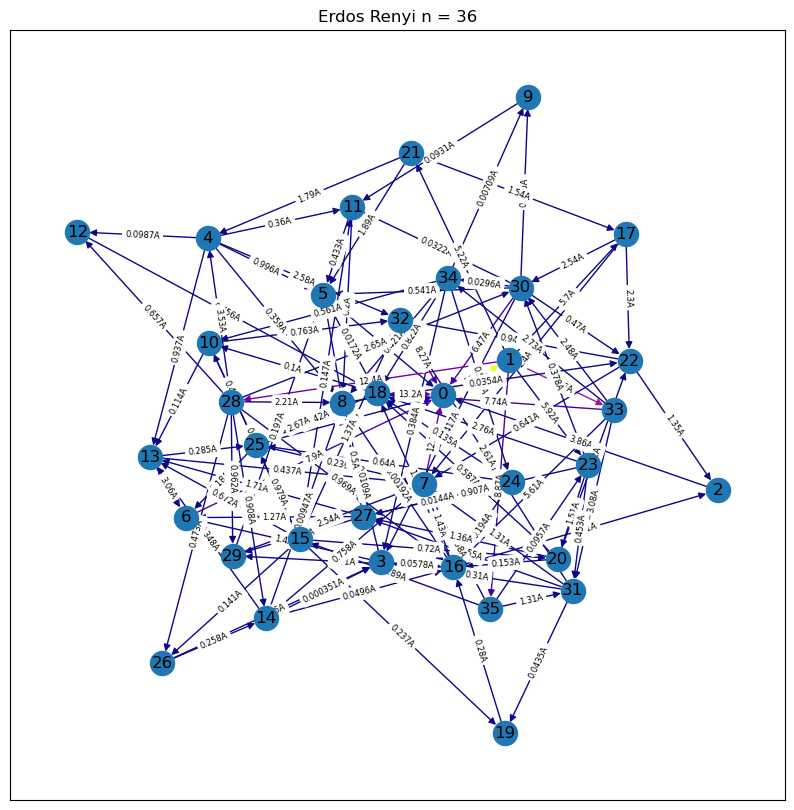

TEST KIRCHOFF 3-Regular n = 36: PASSED


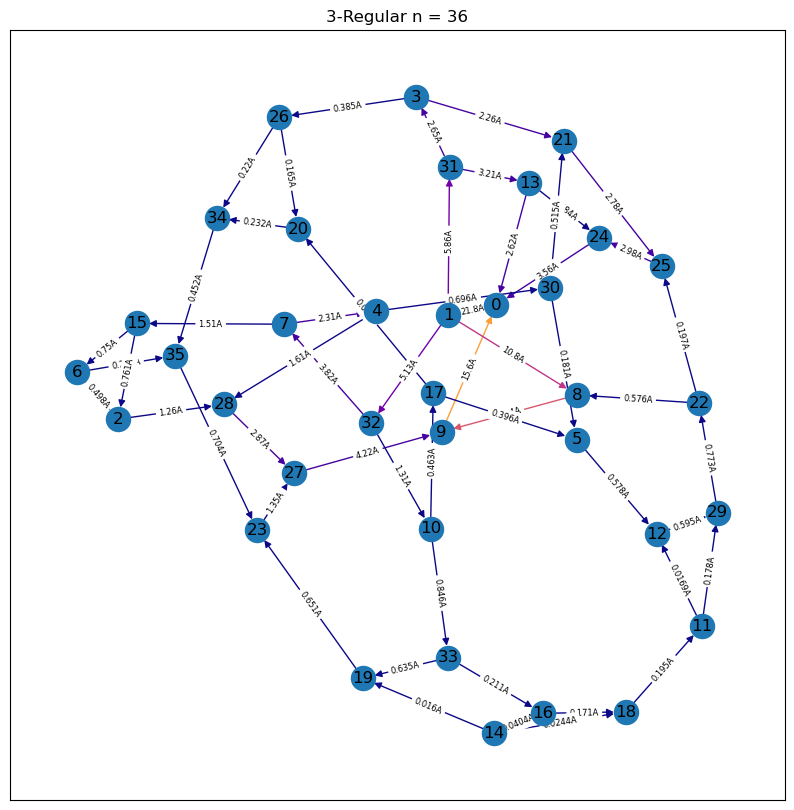

TEST KIRCHOFF Barbell n = 36: PASSED


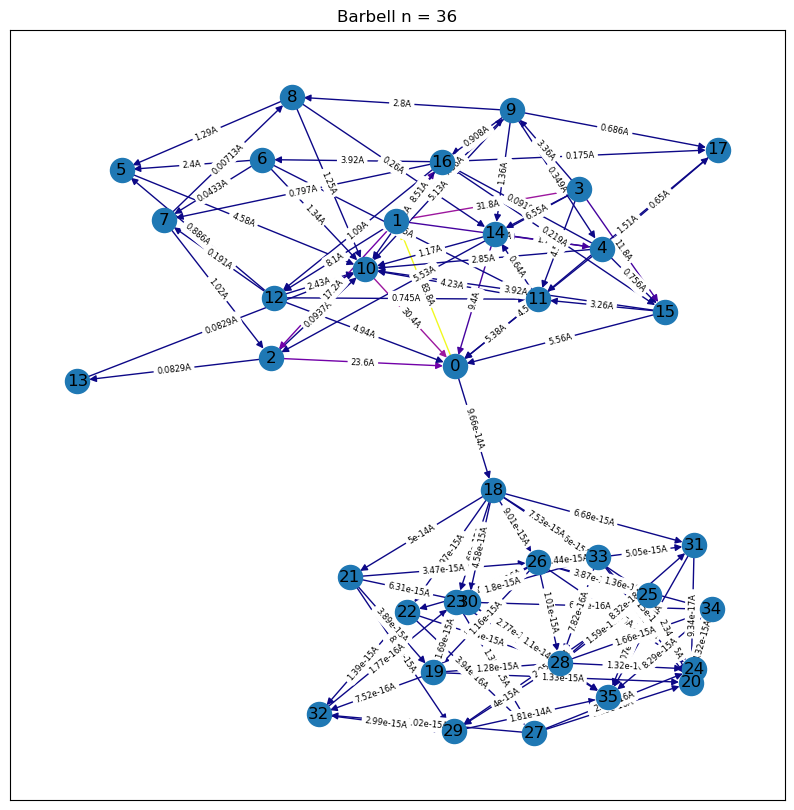

TEST KIRCHOFF Grid 2D n = 36: PASSED


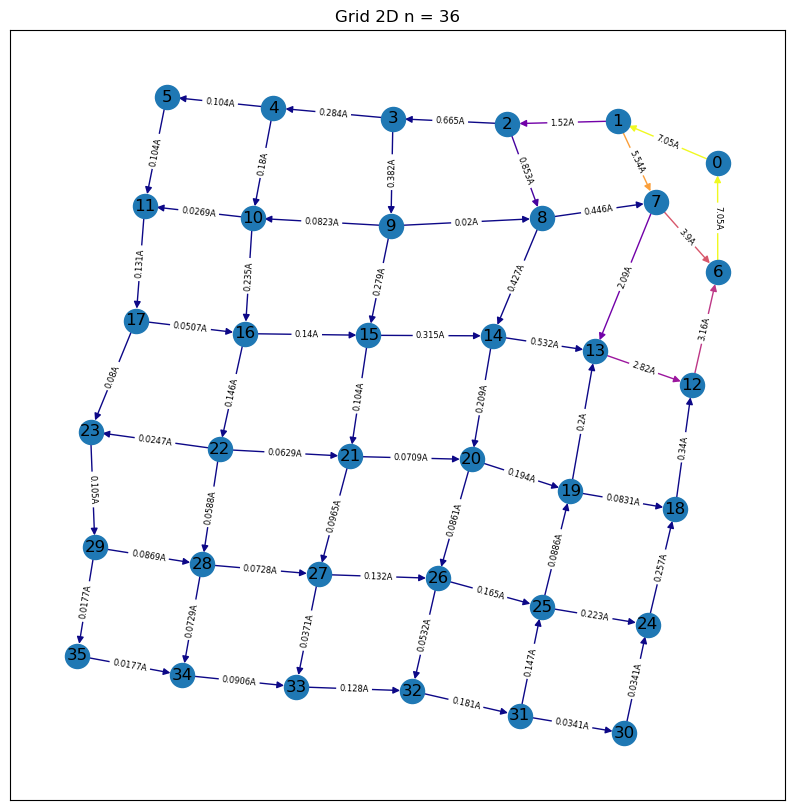

TEST KIRCHOFF Small World n = 36: PASSED


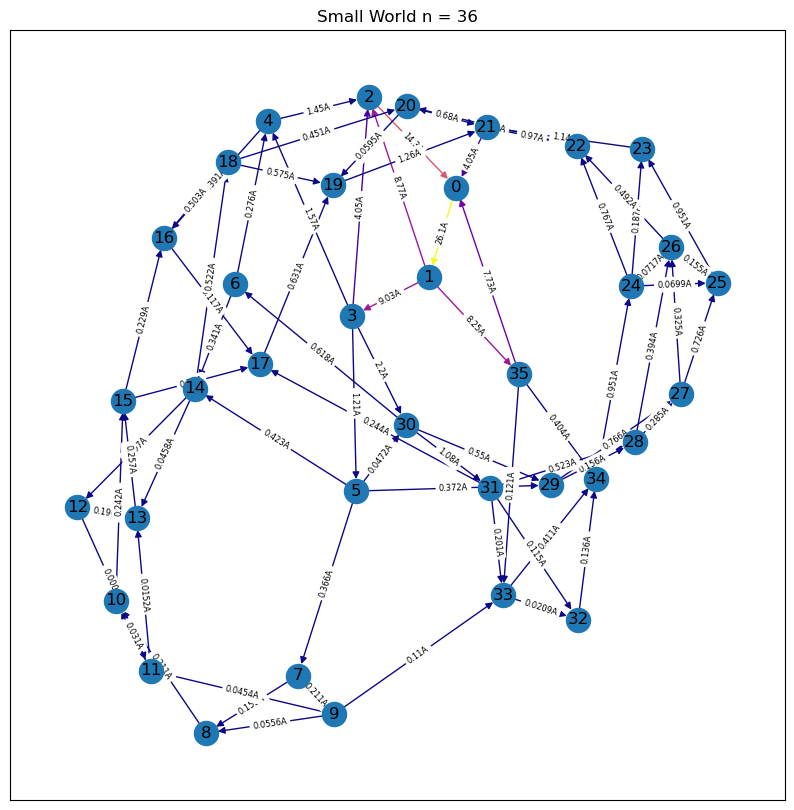

In [23]:
for n in N:
    generate_graphs(n)

    graphs = {
            f"Erdos Renyi n = {n}": f"erdos_renyi_{n}.txt",
            f"3-Regular n = {n}": f"3_regular_{n}.txt",
            f"Barbell n = {n}": f"barbell_{n}.txt",
            f"Grid 2D n = {n}": f"grid_2d_{n}.txt",
            f"Small World n = {n}": f"watts_strogatz_{n}.txt"
            }

    for name, filename in graphs.items():
        G = load_file(filename)
        currents = solve_kirhoff(G,S,T,E)
        solG = to_DiGraph(G,S,T,currents)

        if verify_graph(solG,S,T,E):
            print(f"TEST KIRCHOFF {name}: PASSED")
        else:
            print(f"TEST KIRCHOFF FAILED")
            
        plot_graph(solG,name)

### Poprawność i wizualizacje potencjały wezłowe

TEST NODAL Erdos Renyi n = 36: PASSED


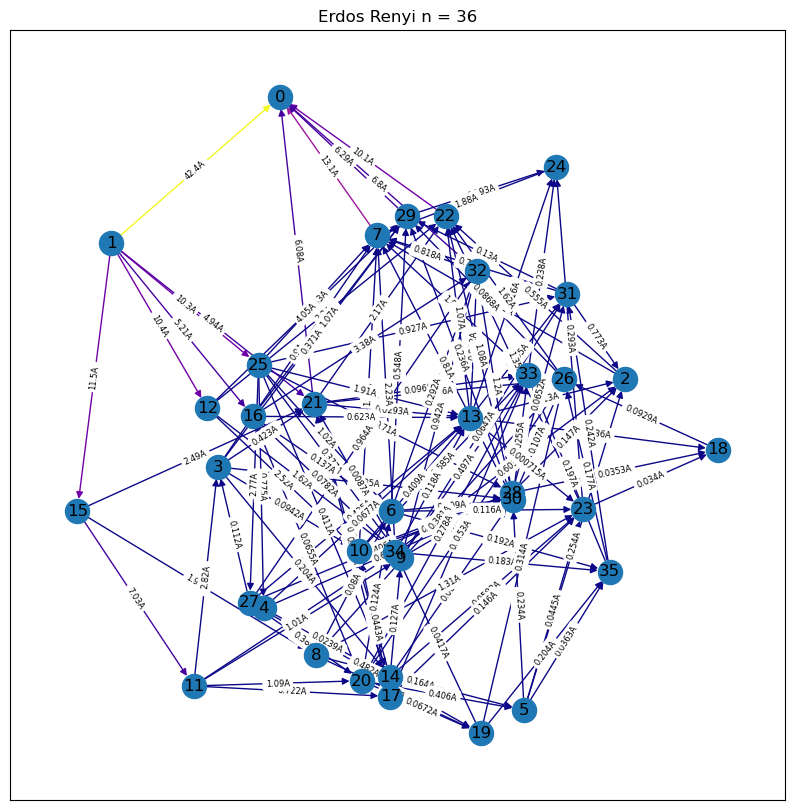

TEST NODAL 3-Regular n = 36: PASSED


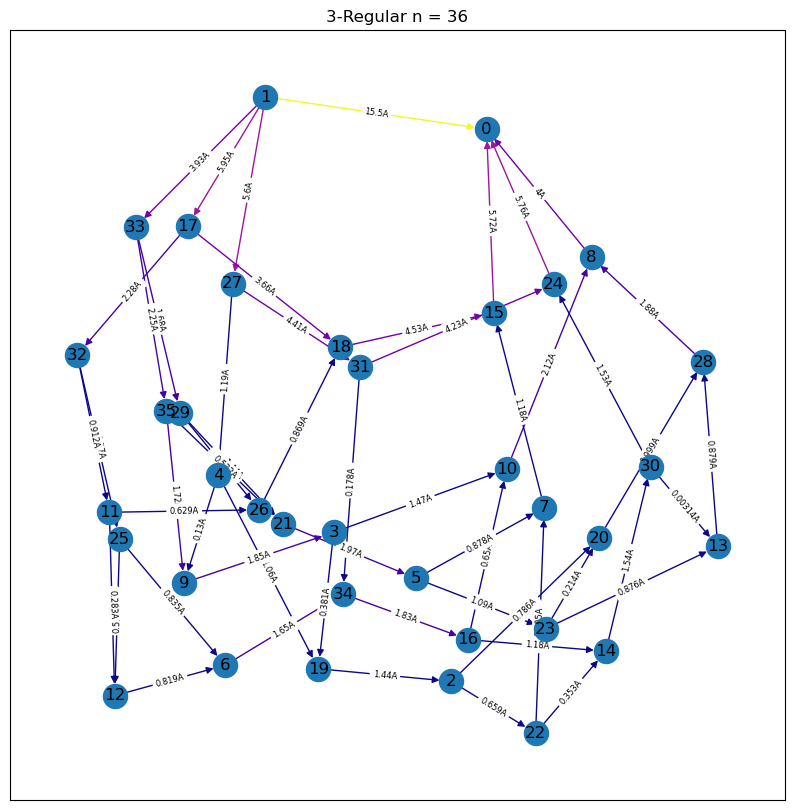

TEST NODAL Barbell n = 36: PASSED


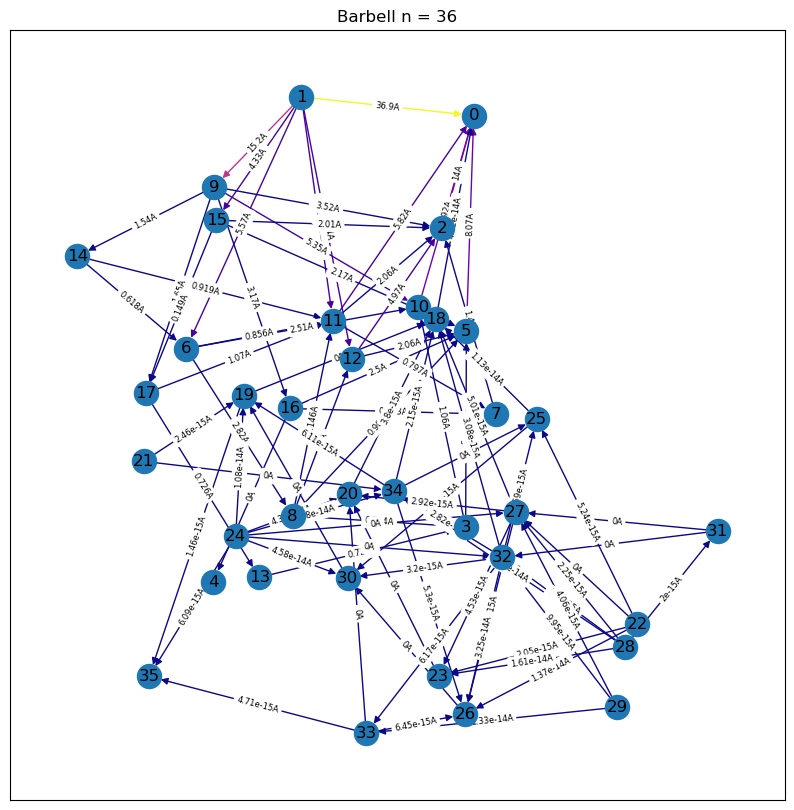

TEST NODAL Grid 2D n = 36: PASSED


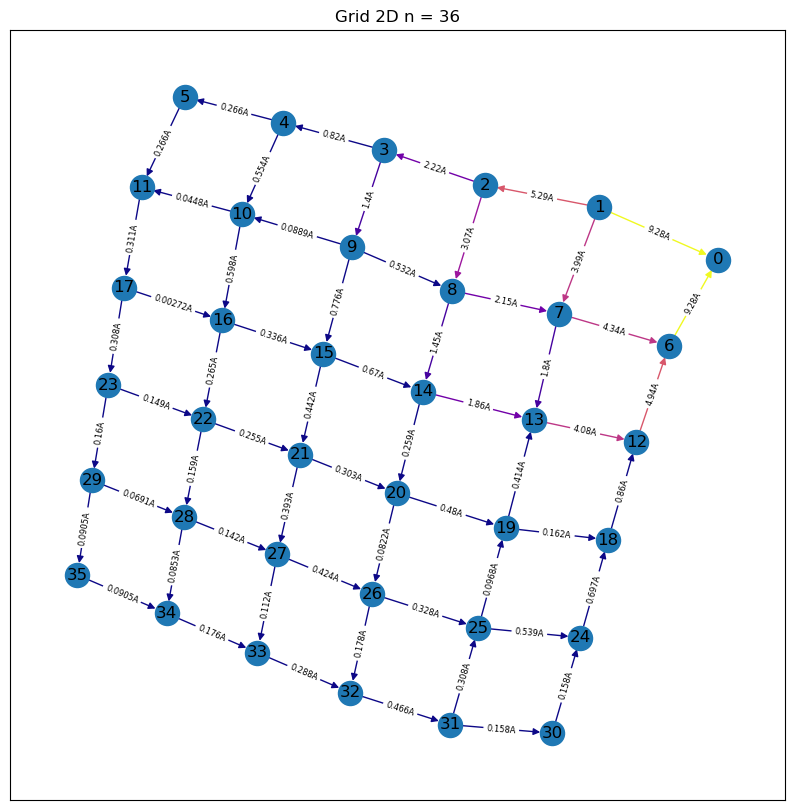

TEST NODAL Small World n = 36: PASSED


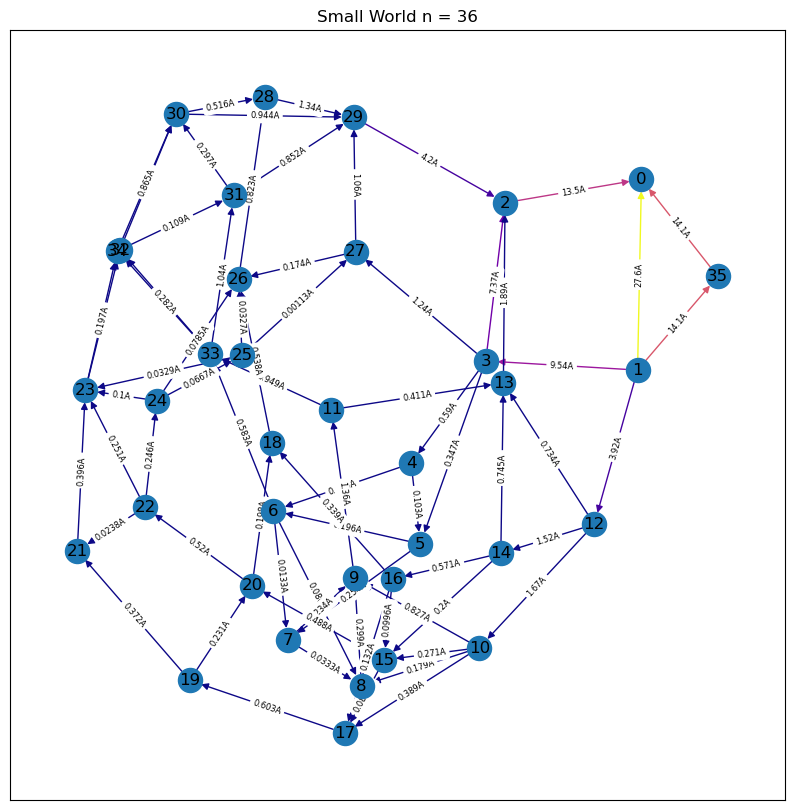

In [24]:
for n in N:
    generate_graphs(n)

    graphs = {
            f"Erdos Renyi n = {n}": f"erdos_renyi_{n}.txt",
            f"3-Regular n = {n}": f"3_regular_{n}.txt",
            f"Barbell n = {n}": f"barbell_{n}.txt",
            f"Grid 2D n = {n}": f"grid_2d_{n}.txt",
            f"Small World n = {n}": f"watts_strogatz_{n}.txt"
            }

    for name, filename in graphs.items():
        G = load_file(filename)
        potentials = solve_nodal(G,S,T,E)
        solG = to_DiGraph(G,S,T,potentials)

        if verify_graph(solG,S,T,E):
            print(f"TEST NODAL {name}: PASSED")
        else:
            print(f"TEST NODAL {name}: FAILED")
            
        plot_graph(solG,name)

### Testy wydajności

In [25]:
x_axis = N_PERF
kir_times = {
    "Erdos Renyi": [],
    "3-Regular": [],
    "Barbell": [],
    "Grid 2D": [],
    "Small World": [],
}
nod_times = {
    "Erdos Renyi": [],
    "3-Regular": [],
    "Barbell": [],
    "Grid 2D": [],
    "Small World": [],
}

for n in N_PERF:
    generate_graphs(n)

    graphs = {
            "Erdos Renyi": f"erdos_renyi_{n}.txt",
            "3-Regular": f"3_regular_{n}.txt",
            "Barbell": f"barbell_{n}.txt",
            "Grid 2D": f"grid_2d_{n}.txt",
            "Small World": f"watts_strogatz_{n}.txt"
            }

    print(f"FOR N = {n}\n--------------------")
    for name, filename in graphs.items():
        G = load_file(filename)
        t0_kir = time()
        _ = solve_kirhoff(G,S,T,E)
        t1_kir = time()

        t0_nod = time()
        _ = solve_nodal(G,S,T,E)
        t1_nod = time()

        kir_times[name].append(t1_kir-t0_kir)
        nod_times[name].append(t1_nod-t0_nod)
        
        print(f"{name}\nKIRCHOFF: {t1_kir-t0_kir:.3f}   NODAL: {t1_nod-t0_nod:.3f}")

    print("--------------------")

FOR N = 36
--------------------
Erdos Renyi
KIRCHOFF: 0.002   NODAL: 0.000
3-Regular
KIRCHOFF: 0.001   NODAL: 0.000
Barbell
KIRCHOFF: 0.001   NODAL: 0.000
Grid 2D
KIRCHOFF: 0.001   NODAL: 0.000
Small World
KIRCHOFF: 0.001   NODAL: 0.000
--------------------
FOR N = 66
--------------------
Erdos Renyi
KIRCHOFF: 0.020   NODAL: 0.001
3-Regular
KIRCHOFF: 0.003   NODAL: 0.001
Barbell
KIRCHOFF: 0.009   NODAL: 0.001
Grid 2D
KIRCHOFF: 0.002   NODAL: 0.000
Small World
KIRCHOFF: 0.002   NODAL: 0.001
--------------------
FOR N = 96
--------------------
Erdos Renyi
KIRCHOFF: 0.187   NODAL: 0.002
3-Regular
KIRCHOFF: 0.002   NODAL: 0.000
Barbell
KIRCHOFF: 0.071   NODAL: 0.001
Grid 2D
KIRCHOFF: 0.002   NODAL: 0.000
Small World
KIRCHOFF: 0.003   NODAL: 0.001
--------------------
FOR N = 126
--------------------
Erdos Renyi
KIRCHOFF: 0.765   NODAL: 0.003
3-Regular
KIRCHOFF: 0.004   NODAL: 0.001
Barbell
KIRCHOFF: 0.321   NODAL: 0.002
Grid 2D
KIRCHOFF: 0.004   NODAL: 0.001
Small World
KIRCHOFF: 0.006   N

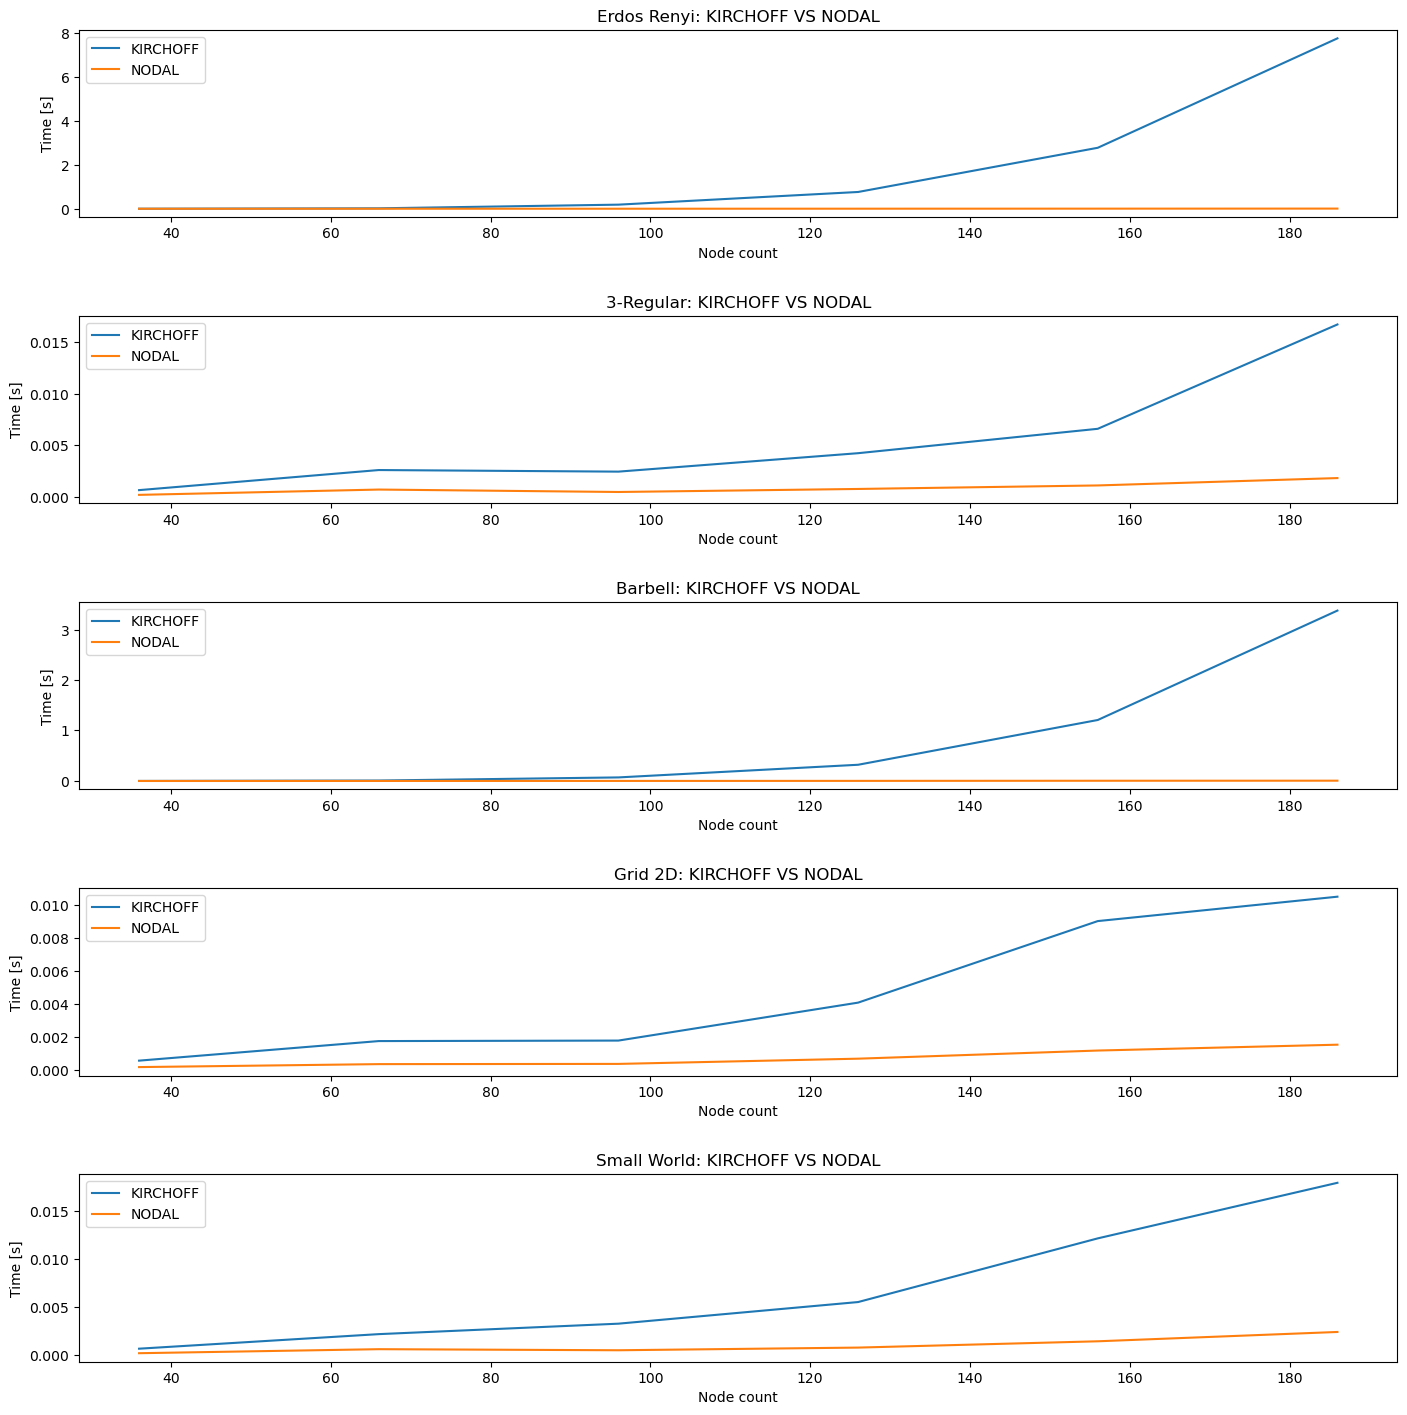

In [26]:
fig, axs = plt.subplots(5, figsize=(15,15))
fig.tight_layout(pad = 5)
names = ["Erdos Renyi","3-Regular","Barbell","Grid 2D","Small World"]
for i, name in enumerate(names):
    axs[i].plot(x_axis, kir_times[name], label = "KIRCHOFF")
    axs[i].plot(x_axis, nod_times[name], label = "NODAL")
    axs[i].legend()
    axs[i].set_title(f"{name}: KIRCHOFF VS NODAL")
    axs[i].set_xlabel("Node count")
    axs[i].set_ylabel("Time [s]")